In [2]:
import pandas as pd

In [13]:
file = "Downloads/HEALTHCARE_ANALYSIS.xlsx"

df = pd.read_excel(file)

df.shape
df.columns
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,False,True,True,False,False,False,True,0


In [14]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], errors='coerce')
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], errors='coerce')

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Date.diff'] = pd.to_numeric(df['Date.diff'], errors='coerce')

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing Values:")
print(df.isnull().sum())

Rows: 106987
Columns: 14

Missing Values:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
Showed_up         0
Date.diff         0
dtype: int64


In [16]:
total_appointments = len(df)

show_up = (df['Showed_up'] == True).sum()
no_show = (df['Showed_up'] == False).sum()

show_up_rate = show_up / total_appointments * 100
no_show_rate = no_show / total_appointments * 100

sms_coverage = (df['SMS_received'] == True).sum() / total_appointments * 100

avg_gap = df['Date.diff'].mean()

print("Total Appointments:", total_appointments)
print("Show-Up Rate:", round(show_up_rate, 2), "%")
print("No-Show Rate:", round(no_show_rate, 2), "%")
print("SMS Coverage:", round(sms_coverage, 2), "%")
print("Average Appointment Gap:", round(avg_gap, 2), "days")

Total Appointments: 106987
Show-Up Rate: 79.74 %
No-Show Rate: 20.26 %
SMS Coverage: 32.33 %
Average Appointment Gap: 10.17 days


In [18]:
attendance_rate = (
    df['Showed_up']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Show-Up / No-Show Rate:")
print(attendance_rate)

Show-Up / No-Show Rate:
Showed_up
True     79.74
False    20.26
Name: proportion, dtype: float64


In [19]:
gender_attendance = pd.crosstab(
    df['Gender'],
    df['Showed_up']
)

print("Gender vs Attendance:")
print(gender_attendance)

Gender vs Attendance:
Showed_up  False  True 
Gender                 
F          14275  55843
M           7405  29464


In [20]:
sms = pd.crosstab(
    df['SMS_received'],
    df['Showed_up']
)

print("SMS vs Attendance:")
print(sms)

SMS vs Attendance:
Showed_up     False  True 
SMS_received              
False         12112  60290
True           9568  25017


In [21]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 35, 50, 65, 120],
    labels=['0-18', '19-35', '36-50', '51-65', '65+']
)

age_attendance = pd.crosstab(
    df['Age_Group'],
    df['Showed_up']
)

print("Age Group vs Attendance:")
print(age_attendance)

Age Group vs Attendance:
Showed_up  False  True 
Age_Group              
0-18        5708  19619
19-35       5753  18384
36-50       4492  17608
51-65       3661  18461
65+         2066  11235


In [22]:
date_diff_attendance = (
    df.groupby('Showed_up')['Date.diff']
    .mean()
    .round(2)
)

print("Average Appointment Gap:")
print(date_diff_attendance)

Average Appointment Gap:
Showed_up
False    15.79
True      8.74
Name: Date.diff, dtype: float64


In [23]:
scholarship = pd.crosstab(
    df['Scholarship'],
    df['Showed_up']
)

print("Scholarship vs Attendance:")
print(scholarship)

Scholarship vs Attendance:
Showed_up    False  True 
Scholarship              
False        19109  77069
True          2571   8238


In [27]:
Hipertension = pd.crosstab(
    df['Hipertension'],
    df['Showed_up']
)

print("Hipertension vs Attendance:")
print(Hipertension)

Hipertension vs Attendance:
Showed_up     False  True 
Hipertension              
False         17908  67278
True           3772  18029


In [28]:
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

monthly_attendance = (
    df.groupby([
        df['AppointmentDay'].dt.to_period('M'),
        'Showed_up'
    ])
    .size()
    .unstack(fill_value=0)
)

print("Monthly Attendance Trend:")
print(monthly_attendance)

Monthly Attendance Trend:
Showed_up       False  True 
AppointmentDay              
2016-04           608   2496
2016-05         16299  61903
2016-06          4773  20908


In [29]:
import matplotlib.pyplot as plt

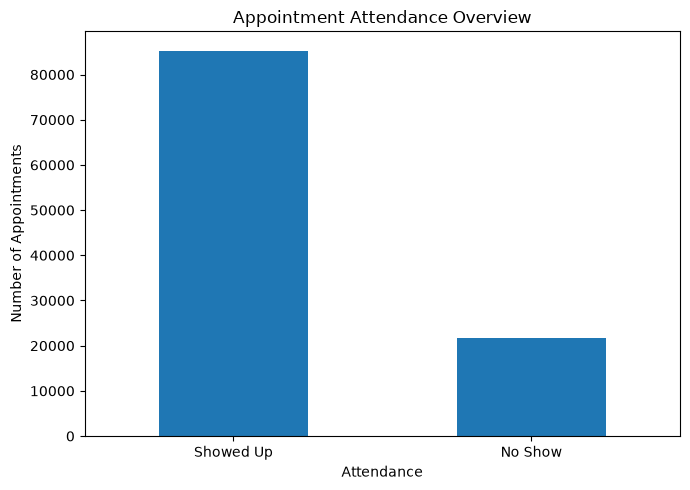

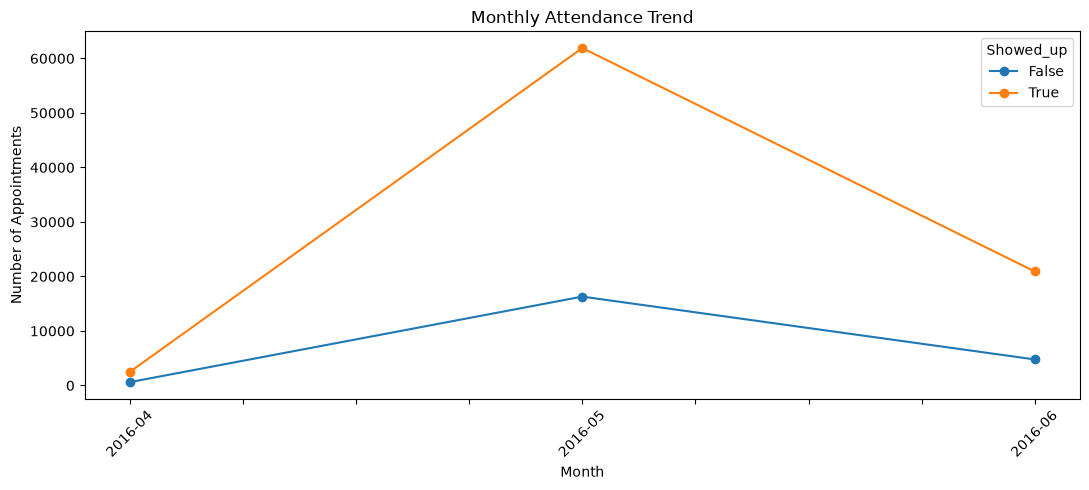

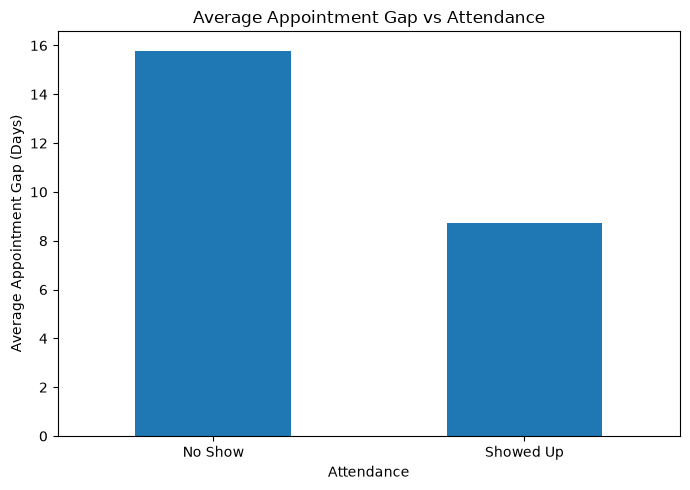

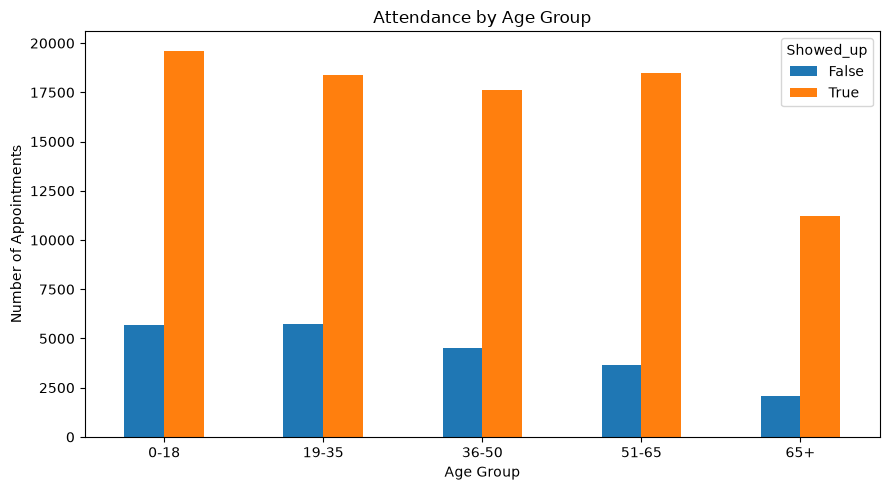

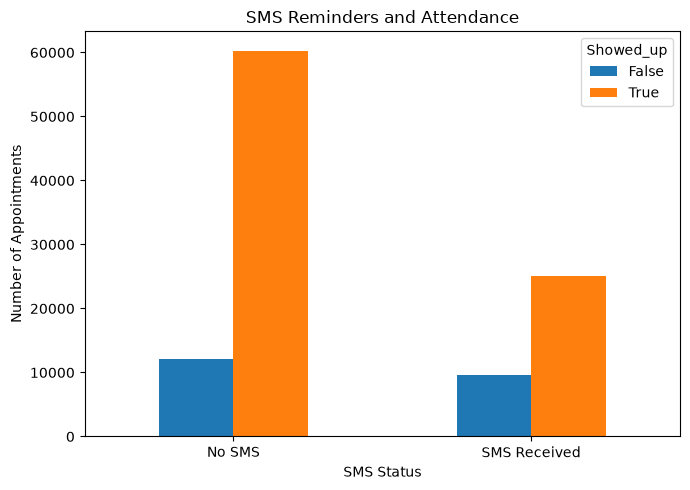

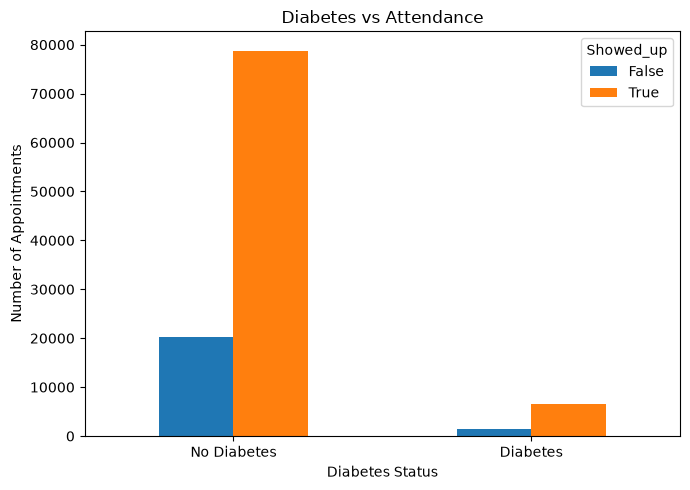

In [31]:
attendance = df['Showed_up'].value_counts()

attendance.index = ['Showed Up' if x == True else 'No Show' for x in attendance.index]

attendance.plot(kind='bar', figsize=(7,5))
plt.title("Appointment Attendance Overview")
plt.xlabel("Attendance")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


monthly = (
    df.groupby([
        df['AppointmentDay'].dt.to_period('M'),
        'Showed_up'
    ])
    .size()
    .unstack(fill_value=0)
)

monthly.index = monthly.index.astype(str)

monthly.plot(kind='line', marker='o', figsize=(11,5))
plt.title("Monthly Attendance Trend")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

gap = df.groupby('Showed_up')['Date.diff'].mean()

gap.index = ['Showed Up' if x == True else 'No Show' for x in gap.index]

gap.plot(kind='bar', figsize=(7,5))
plt.title("Average Appointment Gap vs Attendance")
plt.xlabel("Attendance")
plt.ylabel("Average Appointment Gap (Days)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


age_chart = pd.crosstab(
    df['Age_Group'],
    df['Showed_up']
)

age_chart.plot(kind='bar', figsize=(9,5))
plt.title("Attendance by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


sms_chart = pd.crosstab(
    df['SMS_received'],
    df['Showed_up']
)

sms_chart.index = ['No SMS' if x == False else 'SMS Received'
                   for x in sms_chart.index]

sms_chart.plot(kind='bar', figsize=(7,5))
plt.title("SMS Reminders and Attendance")
plt.xlabel("SMS Status")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


diabetes_chart = pd.crosstab(
    df['Diabetes'],
    df['Showed_up']
)

diabetes_chart.index = [
    'No Diabetes' if x == False else 'Diabetes'
    for x in diabetes_chart.index
]

diabetes_chart.plot(kind='bar', figsize=(7,5))

plt.title("Diabetes vs Attendance")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()